In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


S = 1601, T = 2704
Posterior samples M = 1000

Running PPC for BYM (space-avg, time-resolved)...


PPC BYM: 100%|██████████| 1000/1000 [09:58<00:00,  1.67it/s]



Running PPC for IID (space-avg, time-resolved)...


PPC IID: 100%|██████████| 1000/1000 [07:52<00:00,  2.12it/s]



===== SPACE-AVERAGED TIME-RESOLVED PPC (POSTERIOR RANKING) =====

BYM:
  mean: 0.503
  sd: 0.473
  median: 0.532
  Pr(p < 0.05): 0.426
  Pr(p > 0.95): 0.421

IID:
  mean: 0.494
  sd: 0.473
  median: 0.481
  Pr(p < 0.05): 0.431
  Pr(p > 0.95): 0.411

===== P-VALUE DISTRIBUTION DIAGNOSTICS =====

BYM: KS test for uniformity: statistic=0.3890, p-value=0.0000
IID: KS test for uniformity: statistic=0.3951, p-value=0.0000

(If model fits well, p-values should be approximately uniform)

PPC results saved to:
D:\77\Research\temp\snow\ppc_spaceavg_timeresolved_corrected.npz


C:\Users\lix23\AppData\Local\Temp\ipykernel_9436\3736807332.py:271: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
C:\Users\lix23\AppData\Local\Temp\ipykernel_9436\3736807332.py:277: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()



Visualization saved to: D:\77\Research\temp\snow\ppc_spaceavg_timeresolved_corrected.png


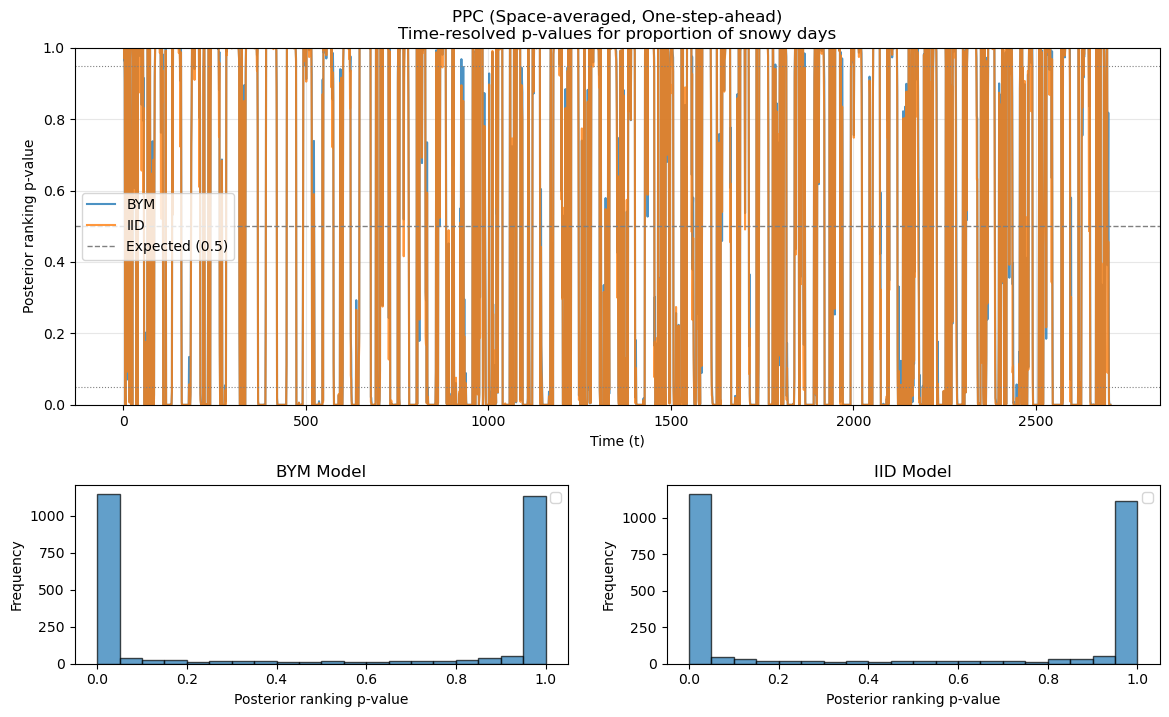

In [3]:
# ================================================================
# PPC: SPACE-AVERAGED, TIME-RESOLVED (ONE-STEP-AHEAD)
# Statistic: proportion of snowy days averaged across space
# CORRECTED VERSION: Simulates replicated datasets
# ================================================================

import numpy as np
import pyreadr
from pathlib import Path
from tqdm import tqdm

# ================================================================
# 0. CONFIG
# ================================================================
BASE_DIR = Path(r"D:\77\Research\temp\snow")
period = 52

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# 1. LOAD DATA (NON-ISOLATED)
# ================================================================
snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

y_full = snow.iloc[:, 2:].to_numpy()
y = np.delete(y_full, no_nbs, axis=0)

S, T = y.shape
print(f"S = {S}, T = {T}")

# ================================================================
# 2. OBSERVED STATISTIC (SPACE-AVERAGED)
# ================================================================
# T_obs[t] = mean_i y_{i,t}, for t = 2..T
T_obs = y[:, 1:].mean(axis=0)    # shape (T-1,)

# ================================================================
# 3. LOAD POSTERIOR SAMPLES
# ================================================================
# BYM
bym01 = np.load(BASE_DIR / "bym01_noIso_final.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10_noIso_final.npz")["all_theta"]

# IID
ind01_full = np.load(BASE_DIR / "ind01.npz")["all_theta"]
ind10_full = np.load(BASE_DIR / "ind10.npz")["all_theta"]

M = bym01.shape[1]
print(f"Posterior samples M = {M}")

# extract non-isolated IID params
S_full = y_full.shape[0]
K_iid = 4

ind01 = np.zeros((K_iid * S, M))
ind10 = np.zeros((K_iid * S, M))

for k in range(K_iid):
    ind01[k*S:(k+1)*S, :] = ind01_full[k*S_full : k*S_full + S, :]
    ind10[k*S:(k+1)*S, :] = ind10_full[k*S_full : k*S_full + S, :]

# ================================================================
# 4. COVARIATES
# ================================================================
# Time index: t = 1,...,T
t_raw = np.arange(1, T + 1)

# IMPORTANT: same scaling rule as in run_bym()
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

# BYM covariates (8 columns)
cov_bym = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/period), np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period), np.sin(2*np.pi*t_raw/period),
    t_trend, t_trend
])

# IID uses single set
cov_iid = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period),
    t_raw
])  # (T, 4)

# ================================================================
# 5. PPC — BYM (TIME-RESOLVED, CORRECTED WITH SIMULATION)
# ================================================================
print("\nRunning PPC for BYM (space-avg, time-resolved)...")

T_pred_bym = np.zeros((M, T-1))

for m in tqdm(range(M), desc="PPC BYM"):
    # Initialize replicated dataset
    y_rep = np.zeros((S, T), dtype=int)
    y_rep[:, 0] = y[:, 0]  # use observed initial state
    
    # Simulate forward in time
    for t in range(1, T):
        # Compute linear predictors
        eta01 = np.zeros(S)
        eta10 = np.zeros(S)

        for k in range(8):
            eta01 += cov_bym[t, k] * bym01[k*S:(k+1)*S, m]
            eta10 += cov_bym[t, k] * bym10[k*S:(k+1)*S, m]

        # Transition probabilities
        p01 = 1 / (1 + np.exp(-eta01))
        p10 = 1 / (1 + np.exp(-eta10))

        # Compute probabilities based on previous SIMULATED state
        prev_state = y_rep[:, t-1]
        prob = np.where(prev_state == 0, p01, 1 - p10)
        
        # SIMULATE binary outcomes
        y_rep[:, t] = np.random.binomial(1, prob)
        
        # Compute space-averaged statistic for this time point
        T_pred_bym[m, t-1] = y_rep[:, t].mean()

# Posterior-ranking p-values
p_time_bym = np.mean(T_obs[None, :] > T_pred_bym, axis=0)

sum_bym = {
    "mean": p_time_bym.mean(),
    "sd": p_time_bym.std(),
    "median": np.median(p_time_bym),
    "Pr(p < 0.05)": np.mean(p_time_bym < 0.05),
    "Pr(p > 0.95)": np.mean(p_time_bym > 0.95),
}

# ================================================================
# 6. PPC — IID (TIME-RESOLVED, CORRECTED WITH SIMULATION)
# ================================================================
print("\nRunning PPC for IID (space-avg, time-resolved)...")

T_pred_iid = np.zeros((M, T-1))

for m in tqdm(range(M), desc="PPC IID"):
    # Initialize replicated dataset
    y_rep = np.zeros((S, T), dtype=int)
    y_rep[:, 0] = y[:, 0]  # use observed initial state
    
    # Simulate forward in time
    for t in range(1, T):
        # Compute linear predictors
        eta01 = np.zeros(S)
        eta10 = np.zeros(S)

        for k in range(4):
            eta01 += cov_iid[t, k] * ind01[k*S:(k+1)*S, m]
            eta10 += cov_iid[t, k] * ind10[k*S:(k+1)*S, m]

        # Transition probabilities
        p01 = 1 / (1 + np.exp(-eta01))
        p10 = 1 / (1 + np.exp(-eta10))

        # Compute probabilities based on previous SIMULATED state
        prev_state = y_rep[:, t-1]
        prob = np.where(prev_state == 0, p01, 1 - p10)
        
        # SIMULATE binary outcomes
        y_rep[:, t] = np.random.binomial(1, prob)
        
        # Compute space-averaged statistic for this time point
        T_pred_iid[m, t-1] = y_rep[:, t].mean()

# Posterior-ranking p-values
p_time_iid = np.mean(T_obs[None, :] > T_pred_iid, axis=0)

sum_iid = {
    "mean": p_time_iid.mean(),
    "sd": p_time_iid.std(),
    "median": np.median(p_time_iid),
    "Pr(p < 0.05)": np.mean(p_time_iid < 0.05),
    "Pr(p > 0.95)": np.mean(p_time_iid > 0.95),
}

# ================================================================
# 7. PRINT SUMMARY
# ================================================================
print("\n===== SPACE-AVERAGED TIME-RESOLVED PPC (POSTERIOR RANKING) =====\n")

print("BYM:")
for k, v in sum_bym.items():
    print(f"  {k}: {v:.3f}")

print("\nIID:")
for k, v in sum_iid.items():
    print(f"  {k}: {v:.3f}")

# ================================================================
# 8. ADDITIONAL DIAGNOSTICS
# ================================================================
print("\n===== P-VALUE DISTRIBUTION DIAGNOSTICS =====\n")

from scipy.stats import kstest

ks_bym = kstest(p_time_bym, 'uniform')
ks_iid = kstest(p_time_iid, 'uniform')

print(f"BYM: KS test for uniformity: statistic={ks_bym.statistic:.4f}, p-value={ks_bym.pvalue:.4f}")
print(f"IID: KS test for uniformity: statistic={ks_iid.statistic:.4f}, p-value={ks_iid.pvalue:.4f}")
print("\n(If model fits well, p-values should be approximately uniform)")

# ================================================================
# 9. SAVE RESULTS
# ================================================================
out_file = BASE_DIR / "ppc_spaceavg_timeresolved_corrected.npz"

np.savez_compressed(
    out_file,
    p_time_bym=p_time_bym,     # (T-1,)
    p_time_iid=p_time_iid,     # (T-1,)
    T_obs=T_obs,               # (T-1,)
    T_pred_bym=T_pred_bym,     # (M, T-1) - full predictive distribution
    T_pred_iid=T_pred_iid,     # (M, T-1) - full predictive distribution
    sum_bym=sum_bym,           # dict
    sum_iid=sum_iid            # dict
)

print(f"\nPPC results saved to:\n{out_file}")

# ================================================================
# 10. VISUALIZATION: TIME SERIES + HISTOGRAM
# ================================================================
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3)

# --- Top panel: Time series of p-values ---
ax1 = fig.add_subplot(gs[0, :])

t = np.arange(2, T + 1)

ax1.plot(t, p_time_bym, label="BYM", lw=1.5, alpha=0.8)
ax1.plot(t, p_time_iid, label="IID", lw=1.5, alpha=0.8)

ax1.axhline(0.5, color="gray", ls="--", lw=1, label="Expected (0.5)")
ax1.axhline(0.05, color="gray", ls=":", lw=0.8)
ax1.axhline(0.95, color="gray", ls=":", lw=0.8)

ax1.set_ylim(0, 1)
ax1.set_xlabel("Time (t)")
ax1.set_ylabel("Posterior ranking p-value")
ax1.set_title(
    "PPC (Space-averaged, One-step-ahead)\n"
    "Time-resolved p-values for proportion of snowy days"
)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Bottom panels: Histograms ---
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

bins = np.linspace(0, 1, 21)
T_len = len(p_time_bym)

ax2.hist(p_time_bym, bins=bins, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Posterior ranking p-value')
ax2.set_ylabel('Frequency')
ax2.set_title('BYM Model')
ax2.legend()

ax3.hist(p_time_iid, bins=bins, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Posterior ranking p-value')
ax3.set_ylabel('Frequency')
ax3.set_title('IID Model')
ax3.legend()

plt.savefig(BASE_DIR / "ppc_spaceavg_timeresolved_corrected.png", dpi=300, bbox_inches='tight')
print(f"\nVisualization saved to: {BASE_DIR / 'ppc_spaceavg_timeresolved_corrected.png'}")
plt.show()